In [16]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [43]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)

In [112]:
print("First 5 records : ")
df.head

First 5 records : 


<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                     

In [110]:
print("Missing values before cleaning :")
df.isnull().sum()

Missing values before cleaning :


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [78]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin']=df['Cabin'].fillna('Unknown')

In [106]:
print("Missing values after cleaning :")
df.isnull().sum()

Missing values after cleaning :


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [108]:
print("Duplicate records :")
df.duplicated().sum()

Duplicate records :


0

In [92]:
df.drop_duplicates(inplace=True)

In [98]:
print("Handling outliers using IQR method")
Q1=df['Fare'].quantile(0.25)
Q3=df['Fare'].quantile(0.75)
IQR=Q3-Q1
lower= Q1-1.5*IQR
upper= Q3+1.5*IQR
outliers= df[(df['Fare']<lower)|(df['Fare']>upper)]
print("Number of Fare outliers are: ", len(outliers))

Handling outliers using IQR method
Number of Fare outliers are:  116


In [116]:
print("tatistical Summary")
df.describe()

tatistical Summary


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Box Plot Visualization :


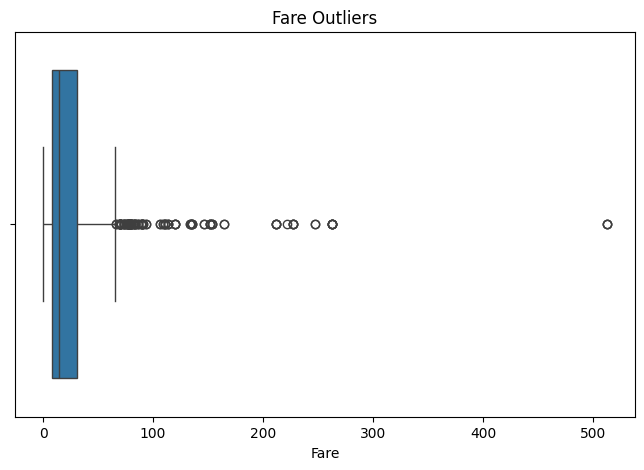

In [132]:
print("Box Plot Visualization :")
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Fare Outliers")
plt.show()

Histogram Visualization : 


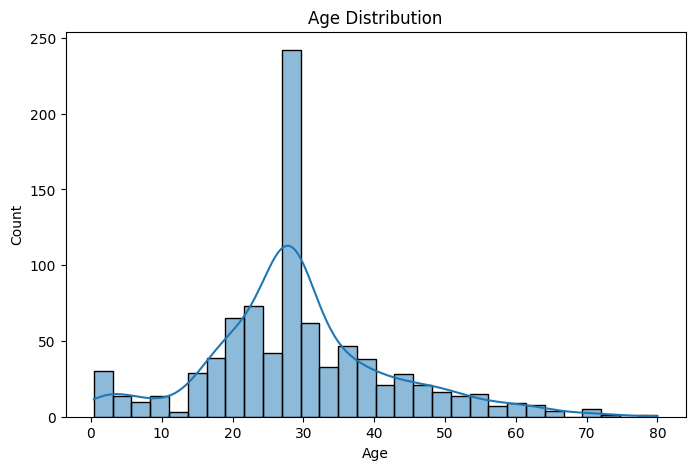

In [138]:
print("Histogram Visualization : ")
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

Countplot Visualization :


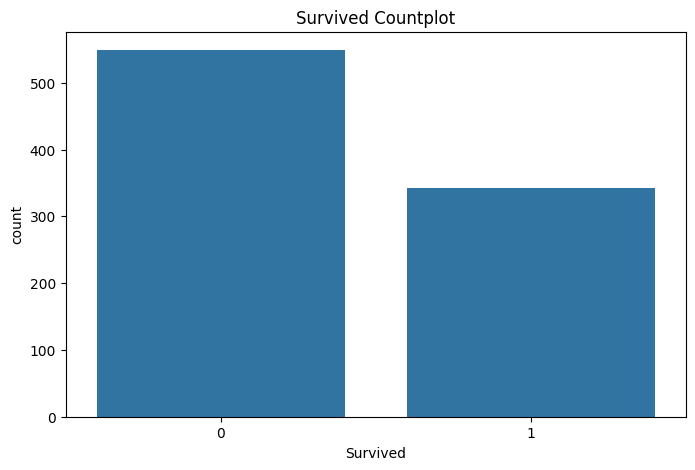

In [144]:
print("Countplot Visualization :")
plt.figure(figsize=(8,5))
sns.countplot(x='Survived',data=df)
plt.title('Survived Countplot')
plt.show()

Survival vs class Countplot Visualization :


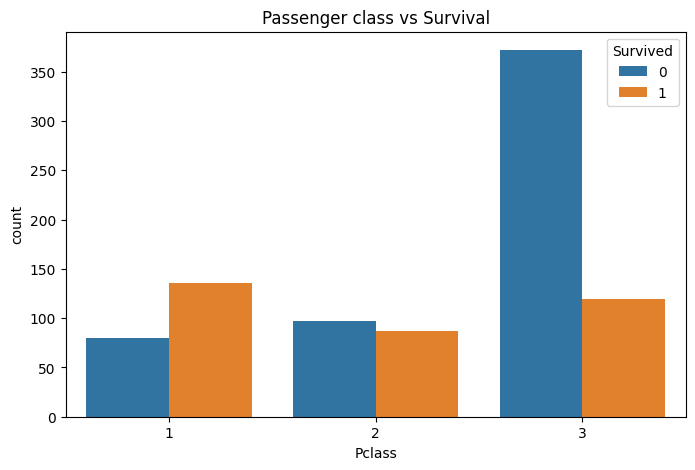

In [152]:
print("Survival vs class Countplot Visualization :")
plt.figure(figsize=(8,5))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Passenger class vs Survival")
plt.show()

Scatterplot Visualization :


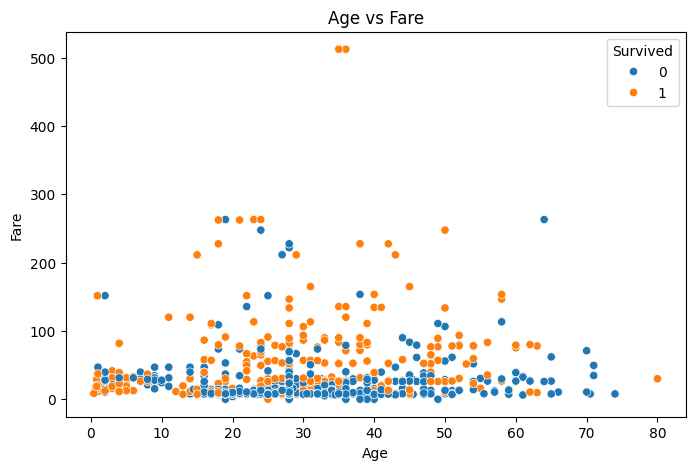

In [158]:
print("Scatterplot Visualization :")
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Age vs Fare')
plt.show()

Correlation Heatmap Visualization :


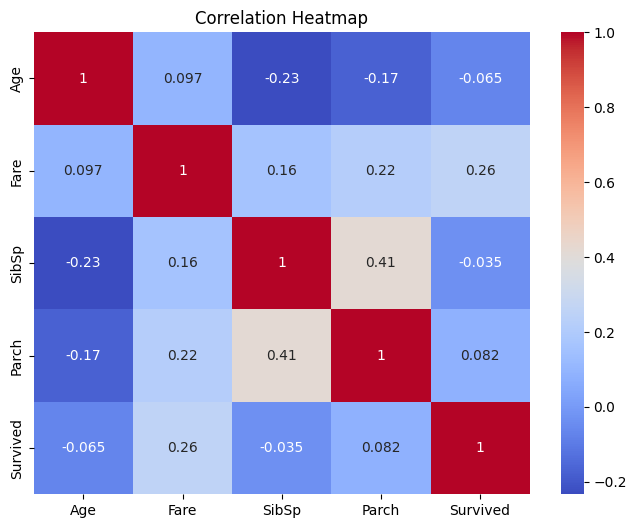

In [164]:
print("Correlation Heatmap Visualization :")
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Age','Fare','SibSp','Parch','Survived']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

In [166]:
print("""
PROJECT INSIGHTS

1. Missing values were cleaned using median, mode, and placeholder values.
2. Duplicate records were removed.
3. Fare outliers were detected using the IQR method.
4. First-class passengers had a higher survival rate.
5. Females generally had a higher survival rate than males.
6. Most passengers were between 20 and 40 years old.
7. Visualizations helped reveal survival patterns and fare distributions.
""")


PROJECT INSIGHTS

1. Missing values were cleaned using median, mode, and placeholder values.
2. Duplicate records were removed.
3. Fare outliers were detected using the IQR method.
4. First-class passengers had a higher survival rate.
5. Females generally had a higher survival rate than males.
6. Most passengers were between 20 and 40 years old.
7. Visualizations helped reveal survival patterns and fare distributions.

